<a href="https://colab.research.google.com/github/Wilson1994/olist-analytics/blob/main/notebook/olist_predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Part 3. Python: simple forecast and recommendations

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

FILE_IN = "https://raw.githubusercontent.com/Wilson1994/olist-analytics/refs/heads/main/data/main_sales_region.csv"

In [47]:
df = pd.read_csv(FILE_IN)

df.head()

,order_id,order_purchase_t,ym,customer_state,category_en,price,freight_value,payment_method,review_score,region
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10,SP,housewares,29.99,8.72,credit_card,4,Southeast
1,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10,SP,housewares,29.99,8.72,voucher,4,Southeast
2,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10,SP,housewares,29.99,8.72,voucher,4,Southeast
3,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-07,BA,perfumery,118.70,22.76,boleto,4,Northeast
4,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 8:38:49,2018-08,GO,auto,159.90,19.22,credit_card,5,Central-West


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113210 entries, 0 to 113209
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   order_id          113210 non-null  object 
 1   order_purchase_t  113210 non-null  object 
 2   ym                113210 non-null  object 
 3   customer_state    113210 non-null  object 
 4   category_en       113210 non-null  object 
 5   price             113210 non-null  float64
 6   freight_value     113210 non-null  float64
 7   payment_method    113210 non-null  object 
 8   review_score      113210 non-null  int64  
 9   region            113210 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 8.6+ MB


In [49]:
df = df.sort_values('ym').reset_index(drop=True)
print("Month", len(df))
df.head()

Month 113210


,order_id,order_purchase_t,ym,customer_state,category_en,price,freight_value,payment_method,review_score,region
0,8213bc96304fc0881189c4525f3002f7,2016-10-10 7:53:34,2016-10,RJ,housewares,32.99,15.56,credit_card,5,Southeast
1,5bda3e4d7080c484cd646a53165a7892,2016-10-07 21:30:12,2016-10,SP,pet_shop,379.98,35.70,voucher,5,Southeast
2,24523db64c1af3f40f27cb4416fa5ea6,2016-10-07 21:19:32,2016-10,RJ,audio,132.00,15.08,credit_card,5,Southeast
3,2631dba338efbcea9c3ace77ce210c01,2016-10-06 8:28:19,2016-10,CE,auto,499.99,94.47,credit_card,5,Northeast
4,9aa3197e4887919fde0307fc23601d7a,2016-10-06 13:16:56,2016-10,SP,fashion_bags_accessories,25.90,8.72,credit_card,4,Southeast


In [50]:
df = df[(df.ym >= '2017-01') & (df.ym <= '2018-08')].reset_index(drop=True)
print("Month (in process)", len(df))
display(df.head(2))
df.tail(2)

Month (in process) 112881


,order_id,order_purchase_t,ym,customer_state,category_en,price,freight_value,payment_method,review_score,region
0,bf9d705db9fe15b5bd6a0a35c3e3365f,2017-01-11 19:21:04,2017-01,SP,baby,119.9,11.45,credit_card,5,Southeast
1,042e247be09aeae88a74e35766aa03ca,2017-01-26 22:28:07,2017-01,RJ,bed_bath_table,59.5,17.16,credit_card,3,Southeast


,order_id,order_purchase_t,ym,customer_state,category_en,price,freight_value,payment_method,review_score,region
112879,575d1ab8d021ded6ab9bd7340d7b7b42,2018-08-07 21:18:38,2018-08,SP,auto,95.90,7.93,credit_card,5,Southeast
112880,c8e84603674d71b14595773f1374773d,2018-08-09 22:31:12,2018-08,RS,telephony,29.99,15.31,boleto,1,South


In [51]:
df.isna().sum()

,0
order_id,0
order_purchase_t,0
ym,0
customer_state,0
category_en,0
price,0
freight_value,0
payment_method,0
review_score,0
region,0


In [52]:
pivot = df.pivot_table(
    values='price',
    index='ym',
    aggfunc = 'sum'
)

pivot

,price
ym,
2017-01,118525.81
2017-02,236110.95
2017-03,370039.64
2017-04,349595.61
2017-05,516270.99
2017-06,437773.82
2017-07,510081.68
2017-08,572738.71
2017-09,635831.10


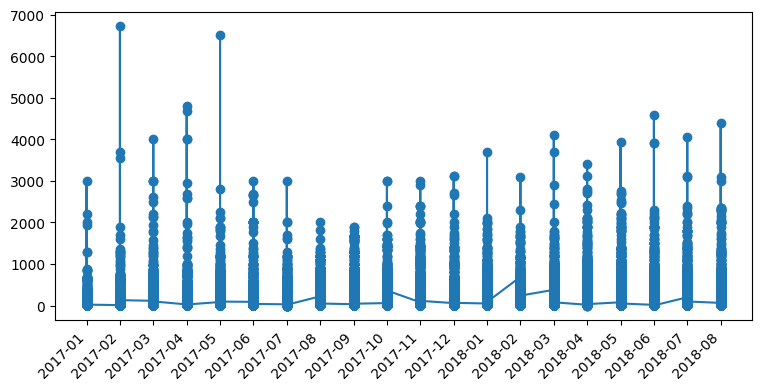

In [53]:
plt.figure(figsize=(9,4))
plt.plot(df.ym, df.price, marker="o")
plt.xticks(rotation=45, ha='right')
plt.show()


In [61]:
df_new = {
    't': list(range(len(pivot))),
    'ym': list(pivot.index),
    'reveue': list(pivot.price)
}


df_new = pd.DataFrame(df_new)
df_new

,t,ym,reveue
0,0,2017-01,118525.81
1,1,2017-02,236110.95
2,2,2017-03,370039.64
3,3,2017-04,349595.61
4,4,2017-05,516270.99
5,5,2017-06,437773.82
6,6,2017-07,510081.68
7,7,2017-08,572738.71
8,8,2017-09,635831.10
9,9,2017-10,655969.70


In [69]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X = df_new[['t']]
y = df_new['revenue']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)
model = LinearRegression().fit(X_train, y_train)
next_index = len(df_new)
y_pred = model.predict(X_test)
forecast = model.predict(pd.DataFrame({
    't': [next_index]
}))[0]
print(f"Predict revenue for next month: R${forecast:,.0f}")
print(f"Average growth for month: R${model.coef_[0]:,.0f}")
print("-" * 15)
print(f"MAE: R${mean_absolute_error(y_test, y_pred):,.0f}")
print(f"RMSE: R${np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")
print(f"Predict accuracy (R2): {r2_score(y_test, y_pred):.1%}")

KeyError: 'revenue'